# SLP From Scratch

In [73]:
import numpy as np

class SLP:
    """
    Single Layer Perceptron (no hidden layers).
    Architecture: Input(n_features) -> Linear -> Sigmoid -> Output(1)
    Loss: Binary Cross-Entropy
    """

    def __init__(self, input_dim):
        # Xavier initialization for sigmoid activation
        scale = np.sqrt(1.0 / input_dim)
        self.W = np.random.randn(input_dim, 1) * scale  # Shape: (n_features, 1)
        self.b = np.zeros((1, 1))  # Bias initialized to zero
        self.losses = []

    @staticmethod
    def sigmoid(Z):
        """Sigmoid activation with clipping to prevent overflow."""
        Z = np.clip(Z, -500, 500)
        return 1 / (1 + np.exp(-Z))

    def forward(self, X):
        """Forward pass: Z = X·W + b, A = sigmoid(Z)"""
        self.X = X
        self.Z = np.dot(X, self.W) + self.b  # (m, n_features) · (n_features, 1) = (m, 1)
        self.A = self.sigmoid(self.Z)
        return self.A

    def compute_loss(self, A, y):
        """Binary Cross-Entropy loss."""
        eps = 1e-8
        A = np.clip(A, eps, 1 - eps)
        return -np.mean(y * np.log(A) + (1 - y) * np.log(1 - A))

    def backward(self, y):
        """Backward pass — gradient of BCE + Sigmoid simplifies to (A - y)."""
        m = y.shape[0]
        dZ = self.A - y  # (m, 1) — simplified gradient for sigmoid + BCE
        dW = np.dot(self.X.T, dZ) / m  # (n_features, 1)
        db = np.sum(dZ, axis=0, keepdims=True) / m  # (1, 1)
        return dW, db

    def predict(self, X):
        """Forward pass and return probabilities."""
        Z = np.dot(X, self.W) + self.b
        return self.sigmoid(Z)

    def train(self, X, y, epochs=10000, learning_rate=0.1, print_every=1000):
        for epoch in range(epochs):
            # Forward
            A = self.forward(X)

            # Loss
            loss = self.compute_loss(A, y)
            self.losses.append(loss)

            # Backward
            dW, db = self.backward(y)

            # Update weights
            self.W -= learning_rate * dW
            self.b -= learning_rate * db

            if print_every and epoch % print_every == 0:
                pred = (A >= 0.5).astype(int)
                acc = np.mean(pred == y)
                print(f"Epoch {epoch:>5d} | Loss: {loss:.6f} | Train Acc: {acc:.4f}")

## Load & Prepare Data

In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the processed attrition dataset
df = pd.read_csv("../data/processed_data_attrition.csv")

# Convert standardized Attrition values back to binary (0 and 1)
attrition_vals = sorted(df["Attrition"].unique())
df["Attrition"] = df["Attrition"].map({attrition_vals[0]: 0, attrition_vals[1]: 1})

# Separate features and target
X = df.drop("Attrition", axis=1).values
y = df["Attrition"].values.reshape(-1, 1)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Features: {X.shape[1]}")
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Attrition rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

Features: 36
Train: 1971 samples | Test: 493 samples
Attrition rate — Train: 50.03% | Test: 49.90%


## Train the SLP

In [75]:
np.random.seed(42)

# SLP: 36 features -> 1 output (sigmoid)  — no hidden layers
model = SLP(input_dim=X_train.shape[1])

model.train(X_train, y_train, epochs=50000, learning_rate=0.05, print_every=1000)

Epoch     0 | Loss: 0.773957 | Train Acc: 0.4921
Epoch  1000 | Loss: 0.445919 | Train Acc: 0.7940
Epoch  2000 | Loss: 0.442350 | Train Acc: 0.7950
Epoch  3000 | Loss: 0.441854 | Train Acc: 0.7935
Epoch  4000 | Loss: 0.441765 | Train Acc: 0.7935
Epoch  5000 | Loss: 0.441747 | Train Acc: 0.7930
Epoch  6000 | Loss: 0.441744 | Train Acc: 0.7930
Epoch  7000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch  8000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch  9000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch 10000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch 11000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch 12000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch 13000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch 14000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch 15000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch 16000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch 17000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch 18000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch 19000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch 20000 | Loss: 

## Training Loss Curve

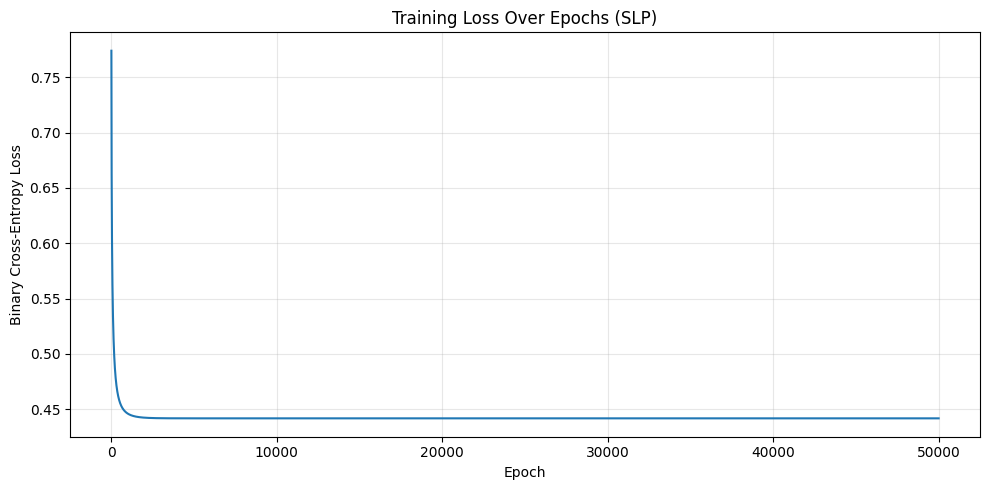

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(model.losses)
plt.title("Training Loss Over Epochs (SLP)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluation on Test Set

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# Predict on test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 40)
print("       SLP Evaluation Results")
print("=" * 40)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("=" * 40)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Attrition", "Attrition"]))

       SLP Evaluation Results
Accuracy:  0.7647
Precision: 0.7519
Recall:    0.7886
F1 Score:  0.7698

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.78      0.74      0.76       247
   Attrition       0.75      0.79      0.77       246

    accuracy                           0.76       493
   macro avg       0.77      0.76      0.76       493
weighted avg       0.77      0.76      0.76       493



## Confusion Matrix

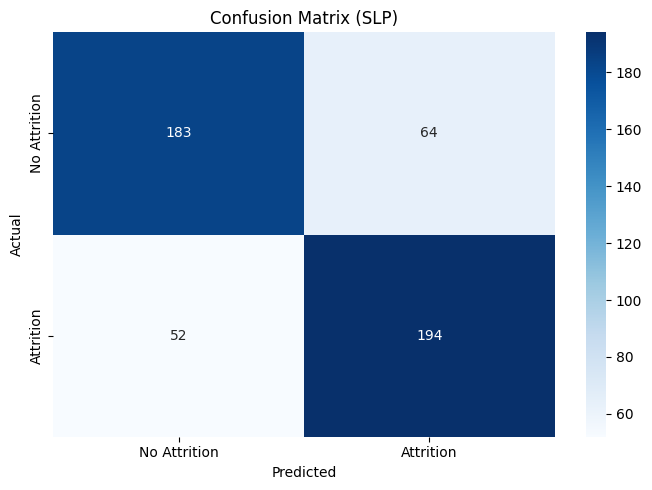

In [78]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix (SLP)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

---
# PyTorch SLP — Comparison
Same architecture: **Input(36) → Linear → Sigmoid → Output(1)** — but using PyTorch with Adam optimizer.

In [79]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert data to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

# PyTorch SLP: Single linear layer + Sigmoid (no hidden layers)
class PyTorchSLP(nn.Module):
    def __init__(self, input_dim):
        super(PyTorchSLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 1),  # Input -> Output (single layer)
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

pytorch_slp = PyTorchSLP(input_dim=X_train.shape[1])
print(pytorch_slp)
print(f"\nTotal parameters: {sum(p.numel() for p in pytorch_slp.parameters()):,}")

PyTorchSLP(
  (network): Sequential(
    (0): Linear(in_features=36, out_features=1, bias=True)
    (1): Sigmoid()
  )
)

Total parameters: 37


## Train PyTorch SLP

In [80]:
torch.manual_seed(42)

criterion = nn.BCELoss()
optimizer = optim.Adam(pytorch_slp.parameters(), lr=0.001)

pytorch_losses = []
epochs = 10000

for epoch in range(epochs):
    y_pred = pytorch_slp(X_train_t)
    loss = criterion(y_pred, y_train_t)
    pytorch_losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        with torch.no_grad():
            pred = (y_pred >= 0.5).float()
            acc = (pred == y_train_t).float().mean()
        print(f"Epoch {epoch:>5d} | Loss: {loss.item():.6f} | Train Acc: {acc.item():.4f}")

Epoch     0 | Loss: 0.684296 | Train Acc: 0.5647
Epoch  1000 | Loss: 0.453991 | Train Acc: 0.7905
Epoch  2000 | Loss: 0.442707 | Train Acc: 0.7965
Epoch  3000 | Loss: 0.441781 | Train Acc: 0.7965
Epoch  4000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch  5000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch  6000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch  7000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch  8000 | Loss: 0.441743 | Train Acc: 0.7935
Epoch  9000 | Loss: 0.441743 | Train Acc: 0.7935


## PyTorch SLP — Loss Curve

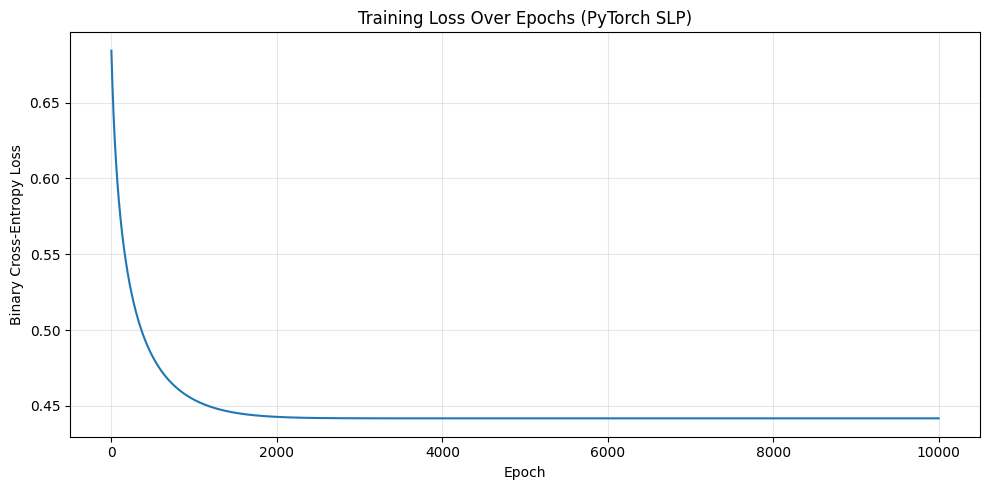

In [81]:
plt.figure(figsize=(10, 5))
plt.plot(pytorch_losses)
plt.title("Training Loss Over Epochs (PyTorch SLP)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## PyTorch SLP — Evaluation

In [82]:
pytorch_slp.eval()
with torch.no_grad():
    y_pred_prob_pt = pytorch_slp(X_test_t).numpy()
    y_pred_pt = (y_pred_prob_pt >= 0.5).astype(int)

accuracy_pt = accuracy_score(y_test, y_pred_pt)
precision_pt = precision_score(y_test, y_pred_pt)
recall_pt = recall_score(y_test, y_pred_pt)
f1_pt = f1_score(y_test, y_pred_pt)

print("=" * 40)
print("   PyTorch SLP Evaluation Results")
print("=" * 40)
print(f"Accuracy:  {accuracy_pt:.4f}")
print(f"Precision: {precision_pt:.4f}")
print(f"Recall:    {recall_pt:.4f}")
print(f"F1 Score:  {f1_pt:.4f}")
print("=" * 40)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pt, target_names=["No Attrition", "Attrition"]))

   PyTorch SLP Evaluation Results
Accuracy:  0.7647
Precision: 0.7519
Recall:    0.7886
F1 Score:  0.7698

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.78      0.74      0.76       247
   Attrition       0.75      0.79      0.77       246

    accuracy                           0.76       493
   macro avg       0.77      0.76      0.76       493
weighted avg       0.77      0.76      0.76       493



## PyTorch SLP — Confusion Matrix

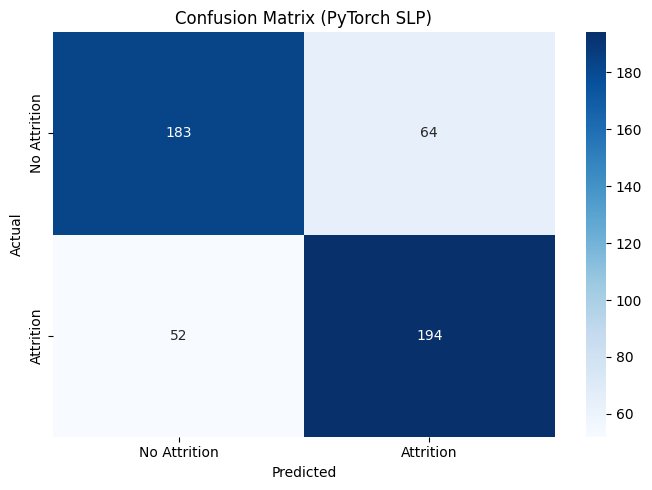

In [83]:
cm_pt = confusion_matrix(y_test, y_pred_pt)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_pt, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix (PyTorch SLP)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## SLP Comparison: From Scratch vs PyTorch

     SLP Comparison: From Scratch vs PyTorch
   Metric  SLP (Scratch)  SLP (PyTorch)
 Accuracy       0.764706       0.764706
Precision       0.751938       0.751938
   Recall       0.788618       0.788618
 F1 Score       0.769841       0.769841


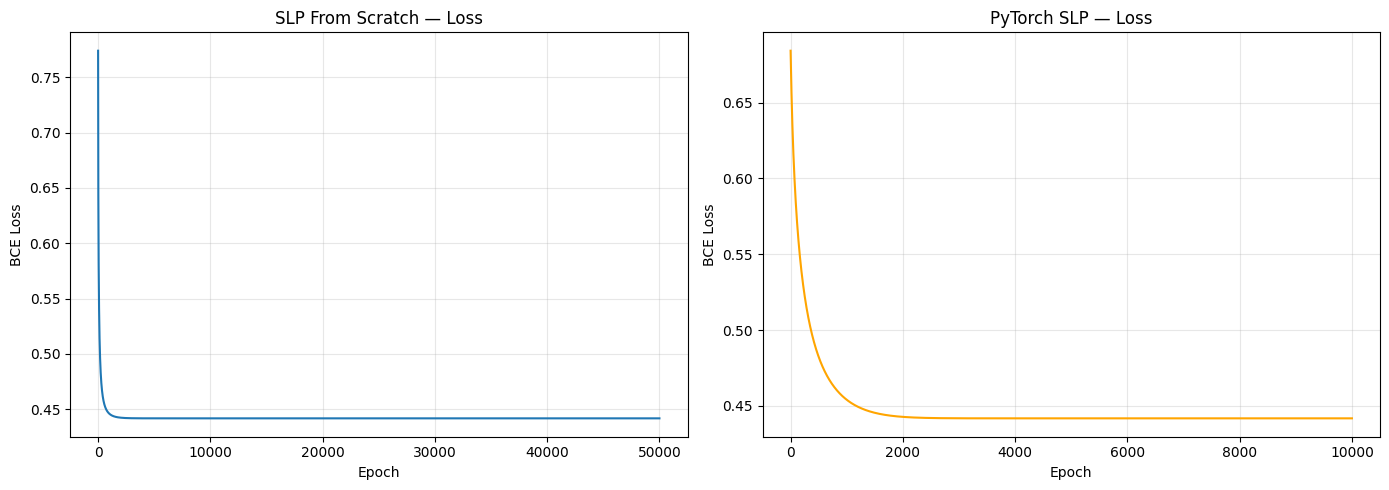

In [84]:
comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "SLP (Scratch)": [accuracy, precision, recall, f1],
    "SLP (PyTorch)": [accuracy_pt, precision_pt, recall_pt, f1_pt]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 55)
print("     SLP Comparison: From Scratch vs PyTorch")
print("=" * 55)
print(comparison_df.to_string(index=False))
print("=" * 55)

# Side-by-side loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model.losses)
axes[0].set_title("SLP From Scratch — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(pytorch_losses, color="orange")
axes[1].set_title("PyTorch SLP — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("BCE Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()